### 演習課題10：1.Embedding+DNN,2.Embeddin+RNN,3.Embedding+BidirectionalRNNの学習モデルを用いて感情分析を行ってきましたが、精度は必ずしも3が最高とはなりませんでした。tensorboardで学習過程をチェックしてみると過学習が起こっていることがわかりました。2もしくは3のハイパーパラメータのチューニングを実行してみて、精度が改善するかどうか試してみてください。精度が良くなっても、そうならなかったとしてもチューニングの過程を含めて実行済みcolabを提出してください。  
### 簡単な考察もコメントとして記述しておくこと。

# RNNとNLP

In [3]:
import keras

# NLP例題：感情分析

In [4]:
#データセットのダウンロード  参考 https://www.tensorflow.org/datasets/overview?hl=ja

import tensorflow_datasets as tfds
imdb, info = tfds.load("imdb_reviews", with_info=True, as_supervised=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.NSNV86_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.NSNV86_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.NSNV86_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.


In [5]:
# コーパスの作成
# 訓練用データ、テスト用データをnp.arrayの形式に変換
import numpy as np

train_data, test_data = imdb['train'], imdb['test']

training_sentences = []
training_labels = []

testing_sentences = []
testing_labels = []

# tf.stringをPython文字列として扱うため、UTF-8のbyte列をdecodeする
for s,l in train_data:
  training_sentences.append(s.numpy().decode("utf-8"))
  training_labels.append(l.numpy())

for s,l in test_data:
  testing_sentences.append(s.numpy().decode("utf-8"))
  testing_labels.append(l.numpy())

training_labels_final = np.array(training_labels)
testing_labels_final = np.array(testing_labels)

In [6]:
len(training_labels_final)

25000

> **Reference**
> - TensorFlow, `tf.keras.layers.TextVectorization`: https://www.tensorflow.org/api_docs/python/tf/keras/layers/TextVectorization
> - TensorFlow guide, Keras preprocessing layers: https://www.tensorflow.org/guide/keras/preprocessing_layers

In [7]:
#コーパスから辞書を作成
#訓練データ、テストデータの作成
vocab_size = 10000  #辞書のサイズ
max_length = 120    #１文の長さの最大値

# Keras 3では古いTokenizer APIではなく、
# standalone kerasのTextVectorizationレイヤーで文章を整数列に変換する。
vectorizer = keras.layers.TextVectorization(
    max_tokens=vocab_size,
    output_mode="int",
    output_sequence_length=max_length,
)
vectorizer.adapt(training_sentences)  #コーパスを学習、トークン化

vocabulary = vectorizer.get_vocabulary()
word_index = {word: index for index, word in enumerate(vocabulary)}  #辞書

# 訓練データ
encoded_padded_sequences = vectorizer(training_sentences)  #文章中の各単語を数字に変換し、max_lengthに長さを揃える
encoded_padded_sequences_np = keras.ops.convert_to_numpy(encoded_padded_sequences).astype("int32")  #NumPy配列に変換した訓練データ

# テストデータ
testing_encoded_padded_sequences = vectorizer(testing_sentences)
testing_encoded_padded_sequences_np = keras.ops.convert_to_numpy(testing_encoded_padded_sequences).astype("int32")  #NumPy配列に変換したテストデータ

In [8]:
#逆辞書の構成
index_word = dict([(value, key) for (key, value) in word_index.items()])

def decode_review(text):  # デコーダ：textは数字の連なり
    return ' '.join([index_word.get(i, '?') for i in text])  #dict.get(key,default)はkeyが与えられたらvalueを返す。ただし、keyが存在しないならばdefaultで指定した値を返す。


## Embedding+DNN

> **Reference**
> - TensorFlow, `tf.keras.layers.Embedding`: https://www.tensorflow.org/api_docs/python/tf/keras/layers/Embedding
> - Keras, Embedding layer: https://keras.io/api/layers/core_layers/embedding/
>

In [9]:
import keras
print(keras.__version__)
print(keras.config.backend())

3.13.2
tensorflow


In [10]:
#モデルの構成とコンパイル
embedding_dim = 16  #word embeddingの次元
model = keras.Sequential([
    keras.Input(shape=(max_length,)), # max_length=１文の長さ
    keras.layers.Embedding(vocab_size, embedding_dim),  # indexをベクトルに変換
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 120, 16)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1920)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       491,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,033 (2.49 MB)

 Trainable params: 652,033 (2.49 MB)

 Non-trainable params: 0 (0.00 B)

> **Reference**
> - Keras, `ModelCheckpoint`: https://keras.io/api/callbacks/model_checkpoint/
> - Keras, `EarlyStopping`: https://keras.io/api/callbacks/early_stopping/
> - Keras, `TensorBoard`: https://keras.io/api/callbacks/tensorboard/

In [11]:
%%time
#lossの変動がなくなったとき途中で学習をやめるように制御したいときはcallbackを使う
callbacks_list = [
                  keras.callbacks.ModelCheckpoint(filepath="dnn.keras", save_best_only=True, monitor="val_acc"),  # 一番よいモデルを保存
                  keras.callbacks.EarlyStopping(monitor="val_acc",patience=10),  #"val_acc"が１０回連続のepochにおいて最高値を更新しなければ停止
                  keras.callbacks.TensorBoard(log_dir="logs")  # 学習状況の可視化
                  ]
#学習の実行
num_epochs = 50
history = model.fit(encoded_padded_sequences_np, training_labels_final, epochs=num_epochs, batch_size=128, validation_split=0.2,callbacks=callbacks_list)

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - acc: 0.6942 - loss: 0.5503 - val_acc: 0.8204 - val_loss: 0.3998
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - acc: 0.8995 - loss: 0.2503 - val_acc: 0.8236 - val_loss: 0.4112
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - acc: 0.9811 - loss: 0.0726 - val_acc: 0.8166 - val_loss: 0.5274
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - acc: 0.9965 - loss: 0.0182 - val_acc: 0.8118 - val_loss: 0.6215
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - acc: 0.9993 - loss: 0.0051 - val_acc: 0.8194 - val_loss: 0.6783
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - acc: 0.9997 - loss: 0.0022 - val_acc: 0.8168 - val_loss: 0.7179
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - acc: 1.0000 - loss: 0.0010 - val_acc: 0.8184 - val_loss: 0.7463
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - acc: 1.0000 - loss: 5.8410e-04 - val_acc: 0.8160 - val_loss: 0.7726
Epoch 9/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 2

In [12]:
#TensorBoard
%load_ext tensorboard
%tensorboard --logdir /content/logs  #絶対パスでlogsの位置を指定

<IPython.core.display.Javascript object>

In [13]:
# 保存した最良モデルの読み込み
model_dnn = keras.models.load_model("dnn.keras")

In [14]:
model_dnn.evaluate(testing_encoded_padded_sequences_np,testing_labels_final)

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - acc: 0.7922 - loss: 0.4655


[0.465526282787323, 0.7922000288963318]

## Embedding+RNN

> **Reference**
> - TensorFlow, `tf.keras.layers.SimpleRNN`: https://www.tensorflow.org/api_docs/python/tf/keras/layers/SimpleRNN

In [15]:
#モデルの構成とコンパイル
model = keras.Sequential([
    keras.Input(shape=(max_length,)),
    keras.layers.Embedding(vocab_size, embedding_dim),
    keras.layers.SimpleRNN(32),  # RNN層: 出力は３２次元とした
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 120, 16)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 170,273 (665.13 KB)

 Trainable params: 170,273 (665.13 KB)

 Non-trainable params: 0 (0.00 B)

> **Reference**
> - Keras, `ModelCheckpoint`: https://keras.io/api/callbacks/model_checkpoint/
> - Keras, `EarlyStopping`: https://keras.io/api/callbacks/early_stopping/
> - Keras, `TensorBoard`: https://keras.io/api/callbacks/tensorboard/

In [16]:
%%time
callbacks_list = [
                  keras.callbacks.ModelCheckpoint(filepath="rnn.keras", save_best_only=True, monitor="val_acc"),  # 一番よいモデルを保存
                  keras.callbacks.EarlyStopping(monitor="val_acc",patience=10),  #"val_acc"が１０回連続のepochにおいて最高値を更新しなければ停止
                  keras.callbacks.TensorBoard(log_dir="logs_rnn")  # 学習状況の可視化
                  ]
#学習の実行
num_epochs = 50
history = model.fit(encoded_padded_sequences_np, training_labels_final, epochs=num_epochs, batch_size=128,validation_split=0.2, callbacks=callbacks_list)

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - acc: 0.5169 - loss: 0.6927 - val_acc: 0.5222 - val_loss: 0.6922
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - acc: 0.7286 - loss: 0.5432 - val_acc: 0.8134 - val_loss: 0.4202
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 44ms/step - acc: 0.8713 - loss: 0.3199 - val_acc: 0.8248 - val_loss: 0.4263
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - acc: 0.9317 - loss: 0.1885 - val_acc: 0.8112 - val_loss: 0.5440
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - acc: 0.9643 - loss: 0.1127 - val_acc: 0.8090 - val_loss: 0.5727
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - acc: 0.9728 - loss: 0.0849 - val_acc: 0.7858 - val_loss: 0.7293
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - acc: 0.9895 - loss: 0.0381 - val_acc: 0.8032 - val_loss: 0.7871
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - acc: 0.9879 - loss: 0.0406 - val_acc: 0.7976 - val_loss: 0.8150
Epoch 9/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms

In [17]:
#TensorBoard
%load_ext tensorboard
# %tensorboard --logdir /content/logs_rnn  --port 6007  #上のtensorboasrdのポート(6006)とは異なるものを指定
%tensorboard --logdir /content/logs_rnn

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


<IPython.core.display.Javascript object>

In [18]:
# 保存した最良モデルの読み込み
model_rnn = keras.models.load_model("rnn.keras")

In [19]:
model_rnn.evaluate(testing_encoded_padded_sequences_np,testing_labels_final)

782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - acc: 0.8071 - loss: 0.4793


[0.47927629947662354, 0.8070799708366394]

## Embedding+BidirectionalRNN

> **Reference**
> - Keras, `Bidirectional` layer: https://keras.io/api/layers/recurrent_layers/bidirectional/
> - TensorFlow, `tf.keras.layers.SimpleRNN`: https://www.tensorflow.org/api_docs/python/tf/keras/layers/SimpleRNN

In [20]:
#モデルの構成とコンパイル
model = keras.Sequential([
    keras.Input(shape=(max_length,)),
    keras.layers.Embedding(vocab_size, embedding_dim, mask_zero=True),  # mask_zero=Trueはpaddingのindex=0を以降の処理では無視させる
    keras.layers.Bidirectional(keras.layers.SimpleRNN(32)),  # bidirectionalにした
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 120, 16)        │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 180,033 (703.25 KB)

 Trainable params: 180,033 (703.25 KB)

 Non-trainable params: 0 (0.00 B)

> **Reference**
> - Keras, `ModelCheckpoint`: https://keras.io/api/callbacks/model_checkpoint/
> - Keras, `EarlyStopping`: https://keras.io/api/callbacks/early_stopping/
> - Keras, `TensorBoard`: https://keras.io/api/callbacks/tensorboard/

In [21]:
%%time
callbacks_list = [
                  keras.callbacks.ModelCheckpoint(filepath="bi_rnn.keras", save_best_only=True, monitor="val_acc"),  # 一番よいモデルを保存
                  keras.callbacks.EarlyStopping(monitor="val_acc",patience=10),  #"val_acc"が１０回連続のepochにおいて最高値を更新しなければ停止
                  keras.callbacks.TensorBoard(log_dir="logs_bi_rnn")  # 学習状況の可視化
                  ]
#学習の実行（時間がかかる（～５分）ので途中で打ち切る）
num_epochs = 50
history = model.fit(encoded_padded_sequences_np, training_labels_final, epochs=num_epochs, batch_size=128,validation_split=0.2,callbacks=callbacks_list)  # 時間がかかるかも。最大７～８分。validateion_split=0.8:設定ミス

Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - acc: 0.7334 - loss: 0.5280 - val_acc: 0.8262 - val_loss: 0.3970
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 96ms/step - acc: 0.8680 - loss: 0.3197 - val_acc: 0.8352 - val_loss: 0.3829
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 94ms/step - acc: 0.9085 - loss: 0.2402 - val_acc: 0.8114 - val_loss: 0.4716
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step - acc: 0.9316 - loss: 0.1831 - val_acc: 0.8222 - val_loss: 0.4408
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - acc: 0.9657 - loss: 0.0994 - val_acc: 0.8072 - val_loss: 0.5213
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - acc: 0.9833 - loss: 0.0513 - val_acc: 0.8118 - val_loss: 0.6988
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 98ms/step - acc: 0.9900 - loss: 0.0294 - val_acc: 0.8214 - val_loss: 0.9206
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 94ms/step - acc: 0.9919 - loss: 0.0239 - val_acc: 0.8162 - val_loss: 0.8862
Epoch 9/50
157/157 ━━━━━━━━━━━━━━━━━━━━

In [22]:
#TensorBoard
%load_ext tensorboard
%tensorboard --logdir /content/logs_bi_rnn
# %tensorboard --logdir /content/logs_bi_rnn  --port 6008

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


<IPython.core.display.Javascript object>

In [23]:
# 保存した最良モデルの読み込み
model_bi_rnn = keras.models.load_model("bi_rnn.keras")

In [24]:
model_bi_rnn.evaluate(testing_encoded_padded_sequences_np,testing_labels_final)

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - acc: 0.8091 - loss: 0.4184


[0.41844308376312256, 0.8091199994087219]

**Additional cell**

In [25]:
import matplotlib.pyplot as plt

def plot_history(history, title="training history"):
    history_dict = history.history

    plt.figure(figsize=(7, 4))
    plt.plot(history_dict.get("acc", []), label="train acc")
    plt.plot(history_dict.get("val_acc", []), label="val acc")
    plt.title(title + " - accuracy")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(history_dict.get("loss", []), label="train loss")
    plt.plot(history_dict.get("val_loss", []), label="val loss")
    plt.title(title + " - loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()
    plt.grid(True)
    plt.show()

## Tuning 1

**Reference**

- Keras, `Dropout`: https://keras.io/api/layers/regularization_layers/dropout/
- Keras, Regularizers: https://keras.io/api/layers/regularizers/
- Keras, `Adam`: https://keras.io/api/optimizers/adam/

In [26]:
embedding_dim_tuned_1 = 32
rnn_units_tuned_1 = 16

model_bi_rnn_tuned_1 = keras.Sequential([
    keras.Input(shape=(max_length,)),
    keras.layers.Embedding(vocab_size, embedding_dim_tuned_1, mask_zero=True),
    keras.layers.Bidirectional(
        keras.layers.SimpleRNN(
            rnn_units_tuned_1,
            dropout=0.2,
            recurrent_dropout=0.2
        )
    ),
    keras.layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(0.001)
    ),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(1, activation="sigmoid")
])

model_bi_rnn_tuned_1.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    metrics=["acc"]
)

model_bi_rnn_tuned_1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 120, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 32)             │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 325,921 (1.24 MB)

 Trainable params: 325,921 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
%%time
callbacks_list_tuned_1 = [
    keras.callbacks.ModelCheckpoint(
        filepath="bi_rnn_tuned_1.keras",
        save_best_only=True,
        monitor="val_acc",
        mode="max"
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_acc",
        patience=5,
        mode="max",
        restore_best_weights=True
    ),
    keras.callbacks.TensorBoard(log_dir="logs_bi_rnn_tuned_1")
]

num_epochs_tuned = 30

history_bi_rnn_tuned_1 = model_bi_rnn_tuned_1.fit(
    encoded_padded_sequences_np,
    training_labels_final,
    epochs=num_epochs_tuned,
    batch_size=128,
    validation_split=0.2,
    callbacks=callbacks_list_tuned_1
)

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 110ms/step - acc: 0.5003 - loss: 0.7462 - val_acc: 0.5086 - val_loss: 0.7302
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 100ms/step - acc: 0.4972 - loss: 0.7315 - val_acc: 0.5068 - val_loss: 0.7222
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 103ms/step - acc: 0.5016 - loss: 0.7229 - val_acc: 0.4962 - val_loss: 0.7172
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 105ms/step - acc: 0.5046 - loss: 0.7165 - val_acc: 0.5014 - val_loss: 0.7124
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - acc: 0.5081 - loss: 0.7122 - val_acc: 0.5090 - val_loss: 0.7090
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 105ms/step - acc: 0.4967 - loss: 0.7100 - val_acc: 0.5024 - val_loss: 0.7065
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - acc: 0.5066 - loss: 0.7058 - val_acc: 0.4996 - val_loss: 0.7042
Epoch 8/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 108ms/step - acc: 0.4972 - loss: 0.7047 - val_acc: 0.5042 - val_loss: 0.7025
Epoch 9/30
157/157 ━━━━━━━━━━━━━

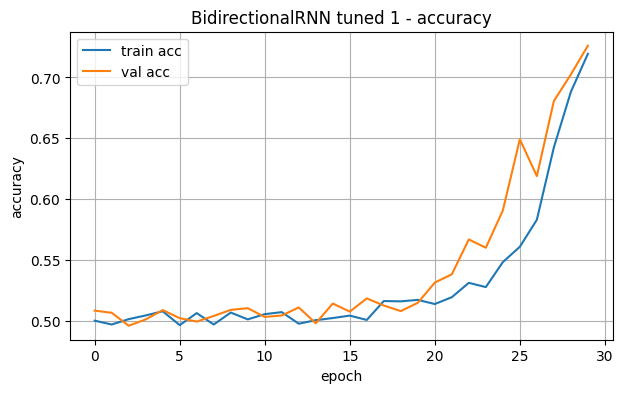

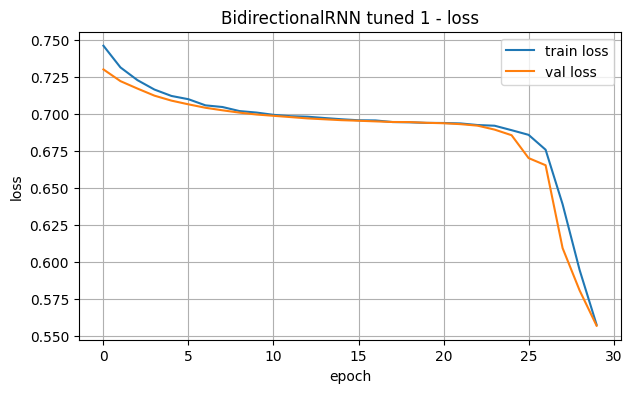

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - acc: 0.7048 - loss: 0.5789


[0.5788848996162415, 0.704800009727478]

In [28]:
plot_history(history_bi_rnn_tuned_1, "BidirectionalRNN tuned 1")

model_bi_rnn_tuned_1 = keras.models.load_model("bi_rnn_tuned_1.keras")
bi_rnn_tuned_1_result = model_bi_rnn_tuned_1.evaluate(
    testing_encoded_padded_sequences_np,
    testing_labels_final
)
bi_rnn_tuned_1_result

## Tuning 2

**Reference**

- TensorFlow, `SimpleRNN`: https://www.tensorflow.org/api_docs/python/tf/keras/layers/SimpleRNN
- Keras, `Bidirectional`: https://keras.io/api/layers/recurrent_layers/bidirectional/
- Keras, `EarlyStopping`: https://keras.io/api/callbacks/early_stopping/

In [29]:
embedding_dim_tuned_2 = 32
rnn_units_tuned_2 = 32

model_bi_rnn_tuned_2 = keras.Sequential([
    keras.Input(shape=(max_length,)),
    keras.layers.Embedding(vocab_size, embedding_dim_tuned_2, mask_zero=True),
    keras.layers.Bidirectional(
        keras.layers.SimpleRNN(
            rnn_units_tuned_2,
            dropout=0.3,
            recurrent_dropout=0.2
        )
    ),
    keras.layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=keras.regularizers.l2(0.0005)
    ),
    keras.layers.Dropout(0.4),
    keras.layers.Dense(1, activation="sigmoid")
])

model_bi_rnn_tuned_2.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=0.0003),
    metrics=["acc"]
)

model_bi_rnn_tuned_2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 120, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,385 (1.25 MB)

 Trainable params: 328,385 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
%%time
callbacks_list_tuned_2 = [
    keras.callbacks.ModelCheckpoint(
        filepath="bi_rnn_tuned_2.keras",
        save_best_only=True,
        monitor="val_acc",
        mode="max"
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_acc",
        patience=5,
        mode="max",
        restore_best_weights=True
    ),
    keras.callbacks.TensorBoard(log_dir="logs_bi_rnn_tuned_2")
]

history_bi_rnn_tuned_2 = model_bi_rnn_tuned_2.fit(
    encoded_padded_sequences_np,
    training_labels_final,
    epochs=num_epochs_tuned,
    batch_size=128,
    validation_split=0.2,
    callbacks=callbacks_list_tuned_2
)

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 113ms/step - acc: 0.4981 - loss: 0.7446 - val_acc: 0.5010 - val_loss: 0.7240
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 118ms/step - acc: 0.5049 - loss: 0.7327 - val_acc: 0.5008 - val_loss: 0.7220
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 110ms/step - acc: 0.5039 - loss: 0.7315 - val_acc: 0.4956 - val_loss: 0.7202
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step - acc: 0.5063 - loss: 0.7255 - val_acc: 0.5134 - val_loss: 0.7179
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 109ms/step - acc: 0.5015 - loss: 0.7254 - val_acc: 0.5046 - val_loss: 0.7164
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step - acc: 0.5002 - loss: 0.7223 - val_acc: 0.5056 - val_loss: 0.7154
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 113ms/step - acc: 0.5015 - loss: 0.7194 - val_acc: 0.5040 - val_loss: 0.7146
Epoch 8/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 117ms/step - acc: 0.4963 - loss: 0.7187 - val_acc: 0.5060 - val_loss: 0.7127
Epoch 9/30
157/157 ━━━━━━━━━━━━━

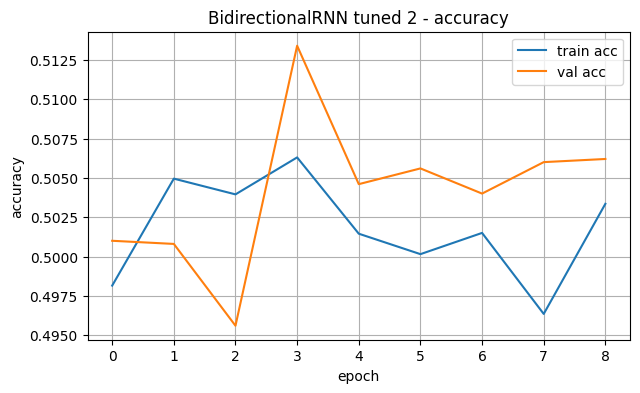

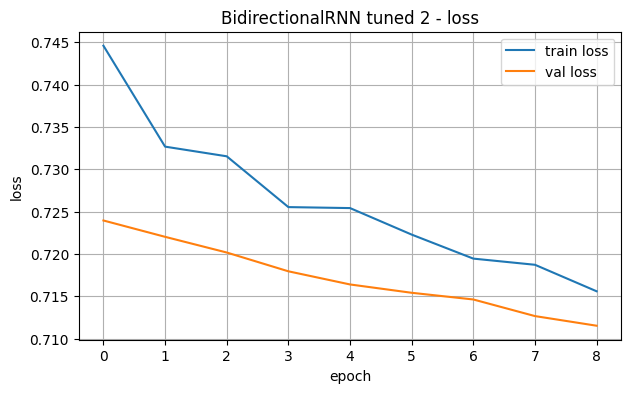

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - acc: 0.5003 - loss: 0.7185


[0.7185434103012085, 0.5002800226211548]

In [31]:
plot_history(history_bi_rnn_tuned_2, "BidirectionalRNN tuned 2")

model_bi_rnn_tuned_2 = keras.models.load_model("bi_rnn_tuned_2.keras")
bi_rnn_tuned_2_result = model_bi_rnn_tuned_2.evaluate(
    testing_encoded_padded_sequences_np,
    testing_labels_final
)
bi_rnn_tuned_2_result

## Result

**Reference**

- Keras, callback: https://keras.io/api/callbacks/tensorboard/

In [32]:
%load_ext tensorboard
%tensorboard --logdir /content/logs_bi_rnn_tuned_1 --port 6009

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


<IPython.core.display.Javascript object>

In [33]:
%tensorboard --logdir /content/logs_bi_rnn_tuned_2 --port 6010

<IPython.core.display.Javascript object>

## test accuracy

In [34]:
import pandas as pd

results = []

model_files = [
    ("Embedding + DNN", "dnn.keras"),
    ("Embedding + RNN", "rnn.keras"),
    ("Embedding + BidirectionalRNN", "bi_rnn.keras"),
    ("BidirectionalRNN tuned 1", "bi_rnn_tuned_1.keras"),
    ("BidirectionalRNN tuned 2", "bi_rnn_tuned_2.keras"),
]

for model_name, model_file in model_files:
    loaded_model = keras.models.load_model(model_file)
    loss, acc = loaded_model.evaluate(
        testing_encoded_padded_sequences_np,
        testing_labels_final,
        verbose=0
    )
    results.append({
        "model": model_name,
        "test_loss": loss,
        "test_acc": acc
    })

results_df = pd.DataFrame(results)
results_df

,model,test_loss,test_acc
0,Embedding + DNN,0.465526,0.79220
1,Embedding + RNN,0.479276,0.80708
2,Embedding + BidirectionalRNN,0.418443,0.80912
3,BidirectionalRNN tuned 1,0.578885,0.70480
4,BidirectionalRNN tuned 2,0.718543,0.50028


## Consideration

今回、Tuningを二つ加えて行ってみたが、元のEmbedding + BidirectionalRNNのtest accuracy：0.80912には及ばない結果となった。


Tuning 1 では、Embeddingの次元数を16から32に増やして、RNNのユニット数を32から16に減らした。また、dropout=0.2、recurrent_dropout=0.2、Dropout(0.5)、L2正則化 l2(0.001) を追加し、学習率を 0.0005 に下げた。


Trial 2 では、RNNのユニット数を 32 に戻し、Dense層を 64 に小さくした。また、dropout=0.3、recurrent_dropout=0.2、Dropout(0.4)、L2正則化 l2(0.0005) を設定し、学習率を 0.0003 に下げた。


元モデルと比べて正則化を強め、過学習を抑えられるかを確認した。